In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [41]:
def simulate_investment(initial_investment, fixed_rate, mean_return, std_dev, proportion_risky, years, simulations):
    proportion_fixed = 1 - proportion_risky
    results = []
    for _ in range(simulations):
        portfolio_value = initial_investment
        for _ in range(years):
            random_return = np.exp(np.random.normal(mean_return, std_dev)) - 1
            portfolio_return = (proportion_fixed * fixed_rate) + ((1 - proportion_fixed) * random_return)
            portfolio_value *= (1 + portfolio_return)
        results.append(portfolio_value)
    mean_end_value = np.mean(results)
    theoretical_return_single_period = proportion_fixed * fixed_rate + proportion_risky * (np.exp(mean_return + 0.5 * std_dev**2) - 1)
    theoretical_end_value   = (1 + theoretical_return_single_period) ** years * initial_investment
    return theoretical_return_single_period, theoretical_end_value, mean_end_value

In [ ]:
a=simulate_investment(1, 0.0025, 0.004, 0.05, 0.5, 24, 10000)
print(a) 

(0.00388190269943725, 1.0974456042155833, 1.0982294535694634)


In [49]:
a_values = []
proportions = np.linspace(0, 1, 11)
for p in proportions:
    _, theor_value, mean_end_value = simulate_investment(1, 0.0025, 0.004, 0.05, p, 24, 10000)
    a_values.append([theor_value, mean_end_value])

In [50]:
a_values

[[1.0617570442619777, 1.0617570442619773],
 [1.068804575054854, 1.0688468978694006],
 [1.0758969231160047, 1.0760082238376545],
 [1.0830343609844255, 1.0836649172947908],
 [1.0902171627806656, 1.0887611768859549],
 [1.0974456042155833, 1.098401854357599],
 [1.1047199625991477, 1.1065172414093394],
 [1.1120405168492282, 1.1112650377330675],
 [1.1194075475005187, 1.116875504958672],
 [1.1268213367134128, 1.1295633298088859],
 [1.1342821682830229, 1.1318521752834898]]

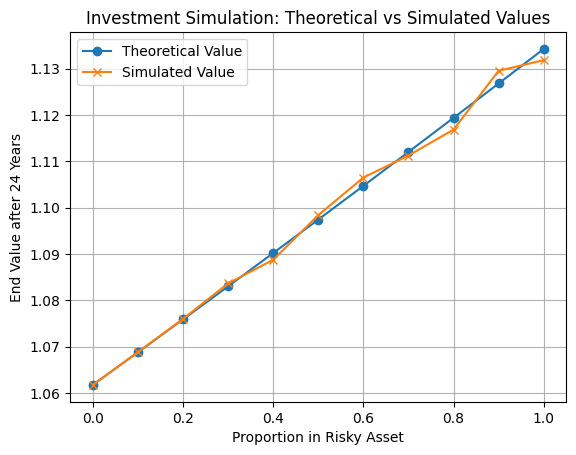

In [51]:
plot_proportions = proportions
theoretical_values = [v[0] for v in a_values]
simulated_values = [v[1] for v in a_values]
plt.plot(plot_proportions, theoretical_values, label='Theoretical Value', marker='o')
plt.plot(plot_proportions, simulated_values, label='Simulated Value', marker='x')
plt.xlabel('Proportion in Risky Asset')
plt.ylabel('End Value after 24 Years')
plt.title('Investment Simulation: Theoretical vs Simulated Values')
plt.legend()
plt.grid()
plt.show()
